# TrustiPay ML + xAI Notebook

This notebook builds a supervised ML model on synthetic transaction data to predict transaction direction (`credit` vs `debit`) using a more production-style workflow.

- **Split strategy**: stratified train / validation / test split
- **Benchmarking**: dummy baseline vs tuned models
- **Evaluation**: cross-validation summary + untouched test-set metrics
- **xAI**: permutation importance + optional SHAP


## 1) Optional package install
Run this only if your kernel is missing packages.

In [11]:
# %pip install -q pandas numpy scikit-learn matplotlib seaborn joblib shap

In [12]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


In [13]:
# Dataset path
DATA_PATH = Path('../synthetic_data/TrustiPay Synthetic Transactions.csv')
if not DATA_PATH.exists():
    # fallback when running notebook from workspace root
    DATA_PATH = Path('synthetic_data/TrustiPay Synthetic Transactions.csv')

df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows from {DATA_PATH}')
df.head()

Loaded 12,000 rows from ../synthetic_data/TrustiPay Synthetic Transactions.csv


,external_tx_id,user_ref,occurred_at,amount,direction,category,description,currency
0,SYN-LARGE-00001,syn-user-0058,2025-01-13T13:08:47Z,11726.14,credit,Other Income,Other Income transaction,LKR
1,SYN-LARGE-00002,syn-user-0053,2025-12-13T19:02:01Z,10563.68,debit,Travel,Travel expense,LKR
2,SYN-LARGE-00003,syn-user-0048,2025-04-22T12:45:41Z,3627.78,debit,Debt,Debt expense,LKR
3,SYN-LARGE-00004,syn-user-0280,2025-08-03T06:48:51Z,14323.11,debit,Debt,Debt expense,LKR
4,SYN-LARGE-00005,syn-user-0082,2025-12-24T16:06:05Z,4096.17,debit,Healthcare,Healthcare expense,LKR


## 1.1) Data visualization (EDA)

Quick exploratory visuals to understand class balance, category mix, amount distribution, and transaction timing before modeling.

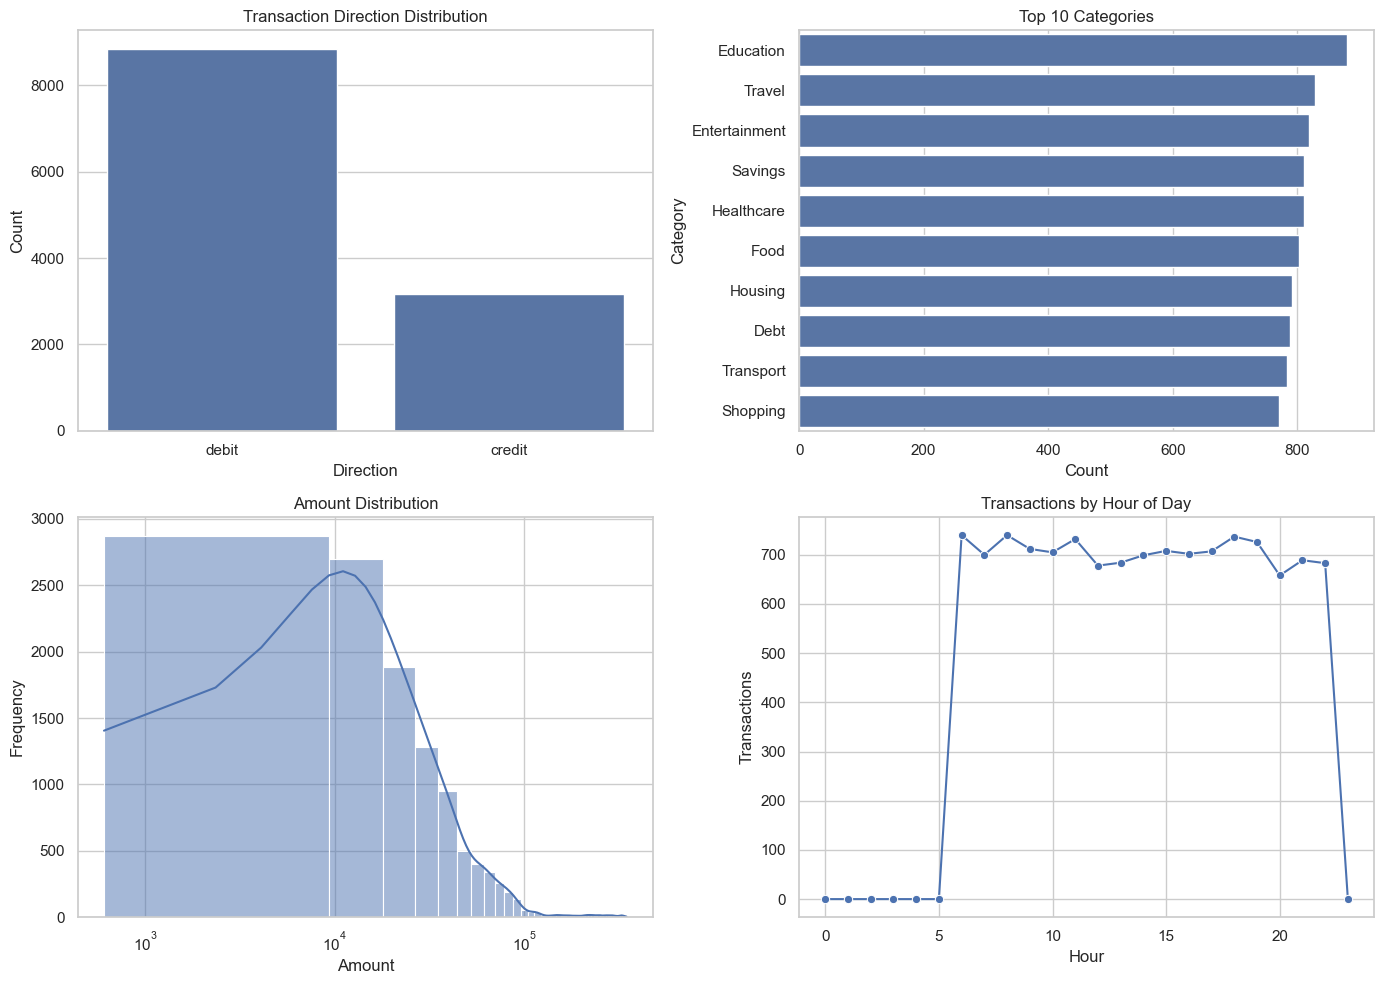

,count,mean,std,min,25%,50%,75%,max
amount,12000.0,31831.522232,42584.522362,606.01,9635.3125,19678.29,37385.0325,348281.74


direction
debit     73.62
credit    26.38
Name: ratio, dtype: float64

In [14]:
# EDA snapshot from raw data before feature engineering
eda_df = df.copy()
eda_df['occurred_at'] = pd.to_datetime(eda_df['occurred_at'], utc=True, errors='coerce')
eda_df['amount'] = pd.to_numeric(eda_df['amount'], errors='coerce')
eda_df = eda_df.dropna(subset=['occurred_at', 'amount', 'direction'])
eda_df['category'] = eda_df['category'].fillna('Unknown')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Direction/class balance
sns.countplot(data=eda_df, x='direction', order=eda_df['direction'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Transaction Direction Distribution')
axes[0, 0].set_xlabel('Direction')
axes[0, 0].set_ylabel('Count')

# 2) Top categories
top_cats = eda_df['category'].value_counts().head(10)
sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Categories')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Category')

# 3) Amount distribution (log scale for readability)
sns.histplot(eda_df['amount'], bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Amount Distribution')
axes[1, 0].set_xlabel('Amount')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xscale('log')

# 4) Hourly transaction pattern
eda_df['hour'] = eda_df['occurred_at'].dt.hour
hour_counts = eda_df.groupby('hour').size().reindex(range(24), fill_value=0)
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Transactions by Hour of Day')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Transactions')

plt.tight_layout()
plt.show()

# quick stats table
display(eda_df[['amount']].describe().T)
display((eda_df['direction'].value_counts(normalize=True).rename('ratio') * 100).round(2))

In [15]:
# Basic cleanup + feature engineering
df = df.copy()
df['occurred_at'] = pd.to_datetime(df['occurred_at'], utc=True, errors='coerce')
df = df.dropna(subset=['occurred_at', 'amount', 'direction'])
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df = df.dropna(subset=['amount'])

df['hour'] = df['occurred_at'].dt.hour
df['day_of_week'] = df['occurred_at'].dt.dayofweek
df['month'] = df['occurred_at'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['category'] = df['category'].fillna('Unknown')
df['currency'] = df['currency'].fillna('Unknown')
df['user_ref'] = df['user_ref'].fillna('unknown-user')

target_col = 'direction'
feature_cols = ['user_ref', 'category', 'currency', 'amount', 'hour', 'day_of_week', 'month', 'is_weekend']

X = df[feature_cols]
y = df[target_col].astype(str)

print('Class distribution:')
print(y.value_counts(normalize=True).rename('ratio'))

Class distribution:
direction
debit     0.736167
credit    0.263833
Name: ratio, dtype: float64


In [16]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_dev,
)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(X_train), len(X_val), len(X_test)],
    'share_of_total': [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
}).round(4)

class_balance = pd.concat(
    {
        'train': y_train.value_counts(normalize=True),
        'validation': y_val.value_counts(normalize=True),
        'test': y_test.value_counts(normalize=True),
    },
    axis=1,
).fillna(0).round(4)

print('Split summary:')
display(split_summary)
print('Class balance by split:')
display(class_balance)

categorical_features = ['user_ref', 'category', 'currency']
numeric_features = ['amount', 'hour', 'day_of_week', 'month', 'is_weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
is_binary_target = y.nunique() == 2


In [17]:
# Model search space (hyperparameter tuning + baseline benchmark)
search_spaces = {
    'logistic_regression': {
        'pipeline': Pipeline([
            ('preprocess', preprocessor),
            ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'params': {
            'clf__C': np.logspace(-3, 2, 20),
            'clf__solver': ['lbfgs', 'liblinear']
        }
    },
    'random_forest': {
        'pipeline': Pipeline([
            ('preprocess', preprocessor),
            ('clf', RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight='balanced_subsample',
                n_jobs=-1
            ))
        ]),
        'params': {
            'clf__n_estimators': [200, 300, 500],
            'clf__max_depth': [None, 8, 12, 16, 24],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4],
            'clf__max_features': ['sqrt', 'log2', None]
        }
    }
}

results = []
best_search = None
best_model_name = None
best_val_f1 = -np.inf

baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_val)

baseline_result = {
    'model': 'dummy_most_frequent',
    'cv_best_f1_weighted': np.nan,
    'cv_std_f1_weighted': np.nan,
    'val_accuracy': accuracy_score(y_val, baseline_pred),
    'val_balanced_accuracy': balanced_accuracy_score(y_val, baseline_pred),
    'val_precision_weighted': precision_score(y_val, baseline_pred, average='weighted', zero_division=0),
    'val_recall_weighted': recall_score(y_val, baseline_pred, average='weighted', zero_division=0),
    'val_f1_weighted': f1_score(y_val, baseline_pred, average='weighted'),
    'val_roc_auc': np.nan,
    'val_pr_auc': np.nan,
    'val_log_loss': np.nan,
    'val_brier_score': np.nan,
    'best_params': {},
}

if is_binary_target and hasattr(baseline_model, 'predict_proba'):
    baseline_labels = list(baseline_model.classes_)
    pos_label = 'credit' if 'credit' in baseline_labels else baseline_labels[1]
    pos_index = baseline_labels.index(pos_label)
    baseline_score = baseline_model.predict_proba(X_val)[:, pos_index]
    y_val_bin = (y_val == pos_label).astype(int)
    baseline_result['val_roc_auc'] = roc_auc_score(y_val_bin, baseline_score)
    baseline_result['val_pr_auc'] = average_precision_score(y_val_bin, baseline_score)
    baseline_result['val_log_loss'] = log_loss(y_val, baseline_model.predict_proba(X_val), labels=baseline_labels)
    baseline_result['val_brier_score'] = brier_score_loss(y_val_bin, baseline_score)

results.append(baseline_result)

for name, cfg in search_spaces.items():
    print(f'\nTuning: {name}')
    search = RandomizedSearchCV(
        estimator=cfg['pipeline'],
        param_distributions=cfg['params'],
        n_iter=16,
        scoring='f1_weighted',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True,
    )
    search.fit(X_train, y_train)

    val_pred = search.best_estimator_.predict(X_val)
    result = {
        'model': name,
        'cv_best_f1_weighted': search.best_score_,
        'cv_std_f1_weighted': search.cv_results_['std_test_score'][search.best_index_],
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_balanced_accuracy': balanced_accuracy_score(y_val, val_pred),
        'val_precision_weighted': precision_score(y_val, val_pred, average='weighted', zero_division=0),
        'val_recall_weighted': recall_score(y_val, val_pred, average='weighted', zero_division=0),
        'val_f1_weighted': f1_score(y_val, val_pred, average='weighted'),
        'val_roc_auc': np.nan,
        'val_pr_auc': np.nan,
        'val_log_loss': np.nan,
        'val_brier_score': np.nan,
        'best_params': search.best_params_,
        'search_obj': search,
    }

    if is_binary_target and hasattr(search.best_estimator_, 'predict_proba'):
        labels = list(search.best_estimator_.classes_)
        pos_label = 'credit' if 'credit' in labels else labels[1]
        pos_index = labels.index(pos_label)
        val_score = search.best_estimator_.predict_proba(X_val)[:, pos_index]
        y_val_bin = (y_val == pos_label).astype(int)
        result['val_roc_auc'] = roc_auc_score(y_val_bin, val_score)
        result['val_pr_auc'] = average_precision_score(y_val_bin, val_score)
        result['val_log_loss'] = log_loss(y_val, search.best_estimator_.predict_proba(X_val), labels=labels)
        result['val_brier_score'] = brier_score_loss(y_val_bin, val_score)

    results.append(result)

    if result['val_f1_weighted'] > best_val_f1:
        best_val_f1 = result['val_f1_weighted']
        best_search = search
        best_model_name = name

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'search_obj'} for r in results])
results_df = results_df.sort_values('val_f1_weighted', ascending=False).reset_index(drop=True)
display(results_df)

baseline_val_f1 = baseline_result['val_f1_weighted']
if baseline_val_f1 >= best_val_f1:
    print('Warning: the tuned models did not outperform the dummy baseline on validation F1.')



Tuning: logistic_regression
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Tuning: random_forest
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/chanupa/anaconda3/envs/resersarch/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


,model,best_cv_score_f1_weighted,test_f1_weighted,test_accuracy,best_params
0,logistic_regression,1.0,1.0,1.0,"{'clf__solver': 'liblinear', 'clf__C': 0.23357..."
1,random_forest,1.0,1.0,1.0,"{'clf__n_estimators': 300, 'clf__min_samples_s..."


Best model params:
{'clf__solver': 'liblinear', 'clf__C': np.float64(0.23357214690901212)}

Classification report:
              precision    recall  f1-score   support

      credit       1.00      1.00      1.00       633
       debit       1.00      1.00      1.00      1767

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



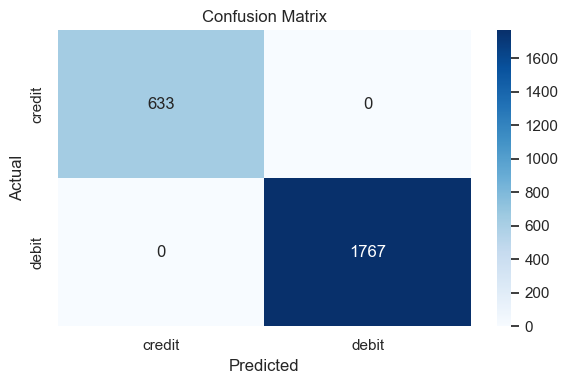

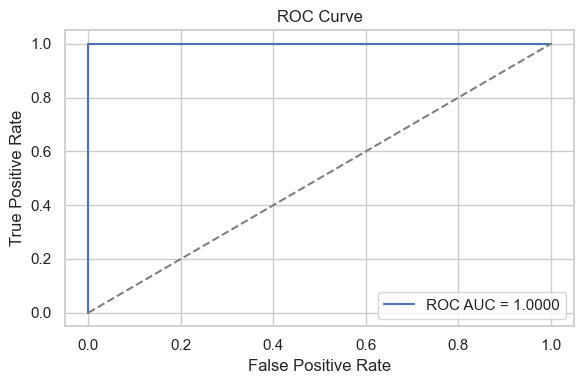

In [18]:
# Final evaluation with best model on the untouched test set
if best_search is None:
    raise RuntimeError('No tuned model was selected. Inspect the search results above.')

print(f'Selected model from validation: {best_model_name}')
print('Best model params:')
print(best_search.best_params_)

best_model = clone(best_search.best_estimator_)
best_model.fit(X_dev, y_dev)

y_pred = best_model.predict(X_test)

test_metrics = {
    'model': best_model_name,
    'test_accuracy': accuracy_score(y_test, y_pred),
    'test_balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
    'test_precision_weighted': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'test_recall_weighted': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'test_f1_weighted': f1_score(y_test, y_pred, average='weighted'),
}

if is_binary_target and hasattr(best_model, 'predict_proba'):
    labels = list(best_model.classes_)
    pos_label = 'credit' if 'credit' in labels else labels[1]
    pos_index = labels.index(pos_label)
    y_score = best_model.predict_proba(X_test)[:, pos_index]
    y_true_bin = (y_test == pos_label).astype(int)

    test_metrics['test_roc_auc'] = roc_auc_score(y_true_bin, y_score)
    test_metrics['test_pr_auc'] = average_precision_score(y_true_bin, y_score)
    test_metrics['test_log_loss'] = log_loss(y_test, best_model.predict_proba(X_test), labels=labels)
    test_metrics['test_brier_score'] = brier_score_loss(y_true_bin, y_score)

print('\nHoldout test metrics:')
display(pd.DataFrame([test_metrics]).round(4))
print('\nClassification report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.title('Confusion Matrix (Holdout Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

if is_binary_target and hasattr(best_model, 'predict_proba'):
    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    precision_curve, recall_curve, _ = precision_recall_curve(y_true_bin, y_score)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(fpr, tpr, label=f'ROC AUC = {test_metrics["test_roc_auc"]:.4f}')
    axes[0].plot([0, 1], [0, 1], '--', color='gray')
    axes[0].set_title('ROC Curve')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()

    axes[1].plot(recall_curve, precision_curve, label=f'PR AUC = {test_metrics["test_pr_auc"]:.4f}', color='teal')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


,feature,importance_mean,importance_std
1,category,0.376235,0.009437
3,amount,0.010969,0.001108
0,user_ref,0.000000,0.000000
2,currency,0.000000,0.000000
4,hour,0.000000,0.000000
5,day_of_week,0.000000,0.000000
6,month,0.000000,0.000000
7,is_weekend,0.000000,0.000000


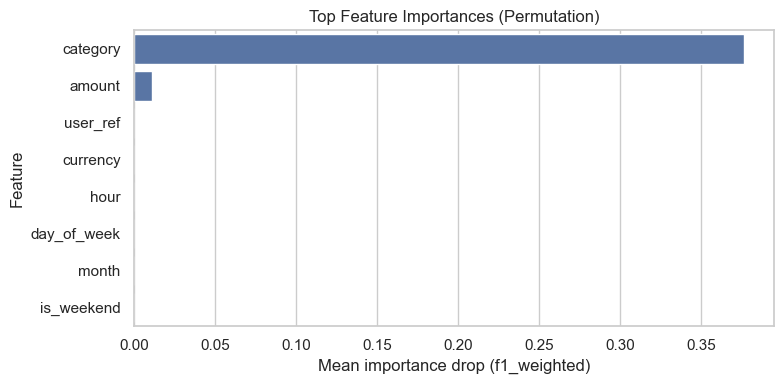

In [19]:
# xAI Part 1: Global explainability via permutation importance
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=42,
    scoring='f1_weighted',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=perm_df.head(10), x='importance_mean', y='feature', orient='h')
plt.title('Top Feature Importances (Permutation)')
plt.xlabel('Mean importance drop (f1_weighted)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [20]:
# xAI Part 2: Optional SHAP (works best for tree model)
try:
    import shap

    clf = best_model.named_steps['clf']
    preprocess = best_model.named_steps['preprocess']

    if isinstance(clf, RandomForestClassifier):
        X_test_transformed = preprocess.transform(X_test)

        # use a manageable sample for SHAP speed
        sample_size = min(300, X_test_transformed.shape[0])
        X_sample = X_test_transformed[:sample_size]

        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_sample)

        feature_names = preprocess.get_feature_names_out()

        # Binary classification: choose class 1 when possible
        if isinstance(shap_values, list) and len(shap_values) > 1:
            shap.summary_plot(shap_values[1], X_sample, feature_names=feature_names, show=False)
        else:
            shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)

        plt.title('SHAP Summary (sample)')
        plt.tight_layout()
        plt.show()
    else:
        print('Best model is not tree-based. SHAP summary is skipped for this run.')
except Exception as exc:
    print(f'SHAP is optional and was skipped: {exc}')

Best model is not tree-based. SHAP summary is skipped for this run.


In [21]:
# Save best model artifact
artifact_path = Path('../synthetic_data/trustipay_best_direction_model.joblib')
if not artifact_path.parent.exists():
    artifact_path = Path('synthetic_data/trustipay_best_direction_model.joblib')

joblib.dump(best_model, artifact_path)
print(f'Saved model to: {artifact_path}')

# Quick single-row inference demo
example_row = X_test.iloc[[0]].copy()
pred = best_model.predict(example_row)[0]
proba = best_model.predict_proba(example_row)[0] if hasattr(best_model, 'predict_proba') else None

print('Example input:')
display(example_row)
print(f'Predicted direction: {pred}')
if proba is not None:
    print('Class probabilities:', dict(zip(best_model.classes_, np.round(proba, 4))))

Saved model to: ../synthetic_data/trustipay_best_direction_model.joblib
Example input:


,user_ref,category,currency,amount,hour,day_of_week,month,is_weekend
6279,syn-user-0190,Entertainment,LKR,15046.02,14,5,12,1


Predicted direction: debit
Class probabilities: {'credit': np.float64(0.026), 'debit': np.float64(0.974)}
